<a href="https://colab.research.google.com/github/bfumia/beginning-bioinformatics/blob/main/SWI_SNF_Chromatin_Conservation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get install muscle
!pip install biopython pandas matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  muscle
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 244 kB of archives.
After this operation, 709 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 muscle amd64 1:3.8.1551-2build1 [244 kB]
Fetched 244 kB in 1s (278 kB/s)
Selecting previously unselected package muscle.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../muscle_1%3a3.8.1551-2build1_amd64.deb ...
Unpacking muscle (1:3.8.1551-2build1) ...
Setting up muscle (1:3.8.1551-2build1) ...
Processing triggers for man-db (2.10.2-1) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 32.7 MB/s eta 0:00:00


In [2]:
import pandas as pd

swi_snf = pd.DataFrame([
    ["BRM",    "AT2G46020", "Q9FYC2"],
    ["CHR12",  "AT3G06050", "Q9SDR4"],
    ["CHR23",  "AT5G19310", "Q9FXE9"],
    ["SWI3A",  "AT2G33610", "Q9LU60"],
    ["SWI3B",  "AT2G47620", "Q9LMI1"],
    ["SWI3C",  "AT1G21700", "Q9S9L0"],
    ["SWI3D",  "AT1G77670", "Q9SPL2"],
    ["ARP7",   "AT3G60830", "Q9LPH5"],
    ["SWP73A", "AT5G14170", "Q9FKG9"],
    ["SWP73B", "AT5G19380", "Q9FKG8"],
], columns=["SWI/SNF Subunit", "TAIR_ID", "UniProt"])

swi_snf

,SWI/SNF Subunit,TAIR_ID,UniProt
0,BRM,AT2G46020,Q9FYC2
1,CHR12,AT3G06050,Q9SDR4
2,CHR23,AT5G19310,Q9FXE9
3,SWI3A,AT2G33610,Q9LU60
4,SWI3B,AT2G47620,Q9LMI1
5,SWI3C,AT1G21700,Q9S9L0
6,SWI3D,AT1G77670,Q9SPL2
7,ARP7,AT3G60830,Q9LPH5
8,SWP73A,AT5G14170,Q9FKG9
9,SWP73B,AT5G19380,Q9FKG8


In [3]:
import requests

def uniprot_fasta(uid, file):
  url = f"https://rest.uniprot.org/uniprotkb/{uid}.fasta"
  r = requests.get(url)
  if r.status_code == 200:
    open(file, "wb").write(r.content)
    print("downloaded", file)
  else:
    print("failed", uid)
for _, row in swi_snf.iterrows():
  uniprot_fasta(row["UniProt"], f"{row['SWI/SNF Subunit']}.fasta")

downloaded BRM.fasta
downloaded CHR12.fasta
downloaded CHR23.fasta
downloaded SWI3A.fasta
downloaded SWI3B.fasta
downloaded SWI3C.fasta
downloaded SWI3D.fasta
downloaded ARP7.fasta
downloaded SWP73A.fasta
downloaded SWP73B.fasta


In [4]:
from Bio.Blast import NCBIWWW
import os

def run_blast(query_file, out_xml):
    seq = open(query_file).read()
    result = NCBIWWW.qblast(
        "blastp",
        "nr",
        seq,
        entrez_query="Oryza sativa[organism]"
    )
    open(out_xml, "w").write(result.read())
    print("BLAST complete:", out_xml)

for _, row in swi_snf.iterrows():
    name = row["SWI/SNF Subunit"]
    fasta_file = f"{name}.fasta"
    blast_xml_file = f"{name}_blast.xml"

    if not os.path.exists(blast_xml_file):
        run_blast(fasta_file, blast_xml_file)
    else:
        print(f"BLAST results already exist for {name}: {blast_xml_file}")


BLAST complete: BRM_blast.xml
BLAST complete: CHR12_blast.xml
BLAST complete: CHR23_blast.xml
BLAST complete: SWI3A_blast.xml
BLAST complete: SWI3B_blast.xml
BLAST complete: SWI3C_blast.xml
BLAST complete: SWI3D_blast.xml
BLAST complete: ARP7_blast.xml
BLAST complete: SWP73A_blast.xml
BLAST complete: SWP73B_blast.xml


In [5]:
from Bio.Blast import NCBIXML
import pandas as pd

top_hits = {}

def parse_top_hits(xml_file, n=3):
    record = NCBIXML.read(open(xml_file))
    hits = []
    for aln in record.alignments[:n]:
        hits.append([aln.hit_def, aln.accession])
    return pd.DataFrame(hits, columns=["Description", "Accession"])

for _, row in swi_snf.iterrows():
    name = row["SWI/SNF Subunit"]
    df = parse_top_hits(f"{name}_blast.xml")
    top_hits[name] = df
    print("=========", name, "=========")
    display(df)

========= BRM =========


,Description,Accession
0,"pheophorbide a oxygenase, chloroplastic-like [...",XP_015633218
1,hypothetical protein OsI_10012 [Oryza sativa I...,EAY88539
2,"RecName: Full=Pheophorbide a oxygenase, chloro...",Q0DV66


========= CHR12 =========


,Description,Accession
0,hypothetical protein OsI_27074 [Oryza sativa I...,EAZ04892
1,dirigent protein 5-like [Oryza sativa Japonica...,XP_025882837
2,dirigent protein 5-like [Oryza sativa Japonica...,XP_066168127


========= CHR23 =========


...

,Description,Accession
0,pentatricopeptide repeat-containing protein At...,NP_001409824
1,hypothetical protein OsJ_25936 [Oryza sativa J...,EAZ41414
2,hypothetical protein OsI_27705 [Oryza sativa I...,EAZ05488


========= SWP73A =========


,Description,Accession
0,hypothetical protein OsI_00782 [Oryza sativa I...,EEC70119
1,autophagy-related protein 3 [Oryza sativa Japo...,XP_015613687
2,LOW QUALITY PROTEIN: autophagy-related protein...,XP_015613096


========= SWP73B =========


,Description,Accession
0,"hypothetical protein EE612_014734, partial [Or...",KAB8089744
1,uncharacterized protein [Oryza sativa Japonica...,XP_015630622
2,"oxidoreductase, zinc-binding dehydrogenase fam...",ABF93481


In [39]:
from Bio import SeqIO
from Bio import Entrez
Entrez.email = "brycefumia6@gmail.com"

def fetch_fasta(acc, outfile):
    handle = Entrez.efetch(db="protein", id=acc, rettype="fasta", retmode = "text")
    seq = SeqIO.read(handle, "fasta")
    seq.id = acc
    seq.name = acc
    seq.description = acc
    SeqIO.write(seq, outfile, "fasta")
    print("Saved:", outfile)

In [27]:
import os

def run_muscle(input_fastas, out_file):
  with open("tmp.fasta","w") as out:
    for f in input_fastas:
      if os.path.exists(f):
          out.write(open(f).read())
      else:
          print(f"Warning: File not found {f}, skipping.")

  !muscle -in tmp.fasta -out $out_file
  print("Aligned:", out_file)

all_fasta_files = []

for _, row in swi_snf.iterrows():
    all_fasta_files.append(f"{row['SWI/SNF Subunit']}.fasta")

for subunit, df_hits in top_hits.items():
    for acc in df_hits["Accession"]:
        all_fasta_files.append(f"{subunit}_{acc}.fasta")

output_alignment_file = "all_swi_snf_and_rice_hits_alignment.fasta"
run_muscle(all_fasta_files, output_alignment_file)


MUSCLE v3.8.1551 by Robert C. Edgar

http://www.drive5.com/muscle
This software is donated to the public domain.
Please cite: Edgar, R.C. Nucleic Acids Res 32(5), 1792-97.

tmp 40 seqs, lengths min 192, max 1165, avg 528
00:00:00     16 MB(4%)  Iter   1  100.00%  K-mer dist pass 1
00:00:00     16 MB(4%)  Iter   1  100.00%  K-mer dist pass 2
00:00:01    40 MB(10%)  Iter   1  100.00%  Align node
00:00:01    40 MB(10%)  Iter   1  100.00%  Root alignment
00:00:01    40 MB(10%)  Iter   2  100.00%  Refine tree
00:00:01    40 MB(10%)  Iter   2  100.00%  Root alignment
00:00:01    40 MB(10%)  Iter   2  100.00%  Root alignment
00:00:04    40 MB(10%)  Iter   3  100.00%  Refine biparts
00:00:07    40 MB(10%)  Iter   4  100.00%  Refine biparts
00:00:09    40 MB(10%)  Iter   5  100.00%  Refine biparts
00:00:09    40 MB(10%)  Iter   5  100.00%  Refine biparts
Aligned: all_swi_snf_and_rice_hits_alignment.fasta


In [29]:
import re
from Bio import Phylo
import matplotlib.pyplot as plt

def clean_fasta(infile, outfile):
    with open(infile) as f, open(outfile, "w") as out:
        for line in f:
            if line.startswith(">"):
                clean = re.sub(r'[^A-Za-z0-9_]', '_', line.strip())
                out.write(clean + "\n")
            else:
                out.write(line)


def check_empty_sequences(fasta):
    current = None
    seq = ""
    empties = []
    with open(fasta) as f:
        for line in f:
            if line.startswith(">"):
                if current and len(seq.strip()) == 0:
                    empties.append(current)
                current = line.strip()
                seq = ""
            else:
                seq += line.strip()
    return empties


def build_tree(aligned_fasta, tree_file):
    print("Running MUSCLE to generate Newick tree...")
    !muscle -maketree -in $aligned_fasta -out $tree_file
    print("Tree saved to:", tree_file)


def plot_tree(tree_file):
    print("Plotting tree...")
    tree = Phylo.read(tree_file, "newick")
    Phylo.draw(tree, do_show=False)
    plt.show()


In [50]:
!apt-get update -qq
!apt-get install -y -qq muscle
!pip install -q biopython matplotlib

import os
from Bio import AlignIO, SeqIO, Phylo
from Bio.Align import MultipleSeqAlignment
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor
import matplotlib.pyplot as plt
import re
import sys

candidates = [f for f in os.listdir() if f.lower().endswith(('.fasta','.fa','.aln'))]
aligned_candidates = [f for f in candidates if ('aligned' in f.lower() or 'align' in f.lower() or 'combined' in f.lower())]
aligned_file = None
if aligned_candidates:
    aligned_file = aligned_candidates[0]
elif candidates:
    aligned_file = candidates[0]

if aligned_file is None:
    raise SystemExit

try:
    alignment = AlignIO.read(aligned_file, "fasta")
except Exception as e:
    raise

nseq = len(alignment)
seqlens = [len(rec.seq) for rec in alignment]
print(f"\nNumber of sequences in alignment: {nseq}")
print("Sequence lengths (min/median/max):", min(seqlens), sorted(seqlens)[len(seqlens)//2], max(seqlens))

empty_ids = [rec.id for rec in alignment if len(rec.seq) == 0]
if empty_ids:
    print("ERROR: The following sequences are empty and will be removed:", empty_ids)
    alignment = MultipleSeqAlignment([rec for rec in alignment if len(rec.seq) > 0])
    nseq = len(alignment)
    if nseq < 2:
        print("Not enough sequences remain after removing empties. Aborting.")
        raise SystemExit

ids = [rec.id for rec in alignment]
dupes = set([x for x in ids if ids.count(x) > 1])
if dupes:
    print("Duplicate sequence IDs detected:", dupes)
else:
    print("No duplicate IDs detected.")

cleaned_records = []
seen = {}
for i, rec in enumerate(alignment):
    safe = re.sub(r'[^A-Za-z0-9_]', '_', rec.id)
    if safe in seen:
        safe = f"{safe}_{i}"
    seen[safe] = True
    rec.id = safe
    rec.name = safe
    rec.description = ""
    cleaned_records.append(rec)

cleaned_alignment = MultipleSeqAlignment(cleaned_records)

cleaned_file = "cleaned_for_tree.fasta"
AlignIO.write(cleaned_alignment, cleaned_file, "fasta")
print(f"\nCleaned alignment written to: {cleaned_file} (seq count: {len(cleaned_alignment)})")

if len(cleaned_alignment) < 2:
    print("Need at least 2 sequences to build a tree.")
    raise SystemExit

calc = DistanceCalculator('identity')
dm = calc.get_distance(cleaned_alignment)
constructor = DistanceTreeConstructor()
nj_tree = constructor.nj(dm)

try:
    nj_tree.root_at_midpoint()
except Exception:
    pass

tree_file = "combined_swi_snf_rice_tree.nwk"
Phylo.write(nj_tree, tree_file, "newick")
print(f"Tree saved to {tree_file}")




W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

Number of sequences in alignment: 40
Sequence lengths (min/median/max): 1585 1585 1585
No duplicate IDs detected.

Cleaned alignment written to: cleaned_for_tree.fasta (seq count: 40)
Tree saved to combined_swi_snf_rice_tree.nwk


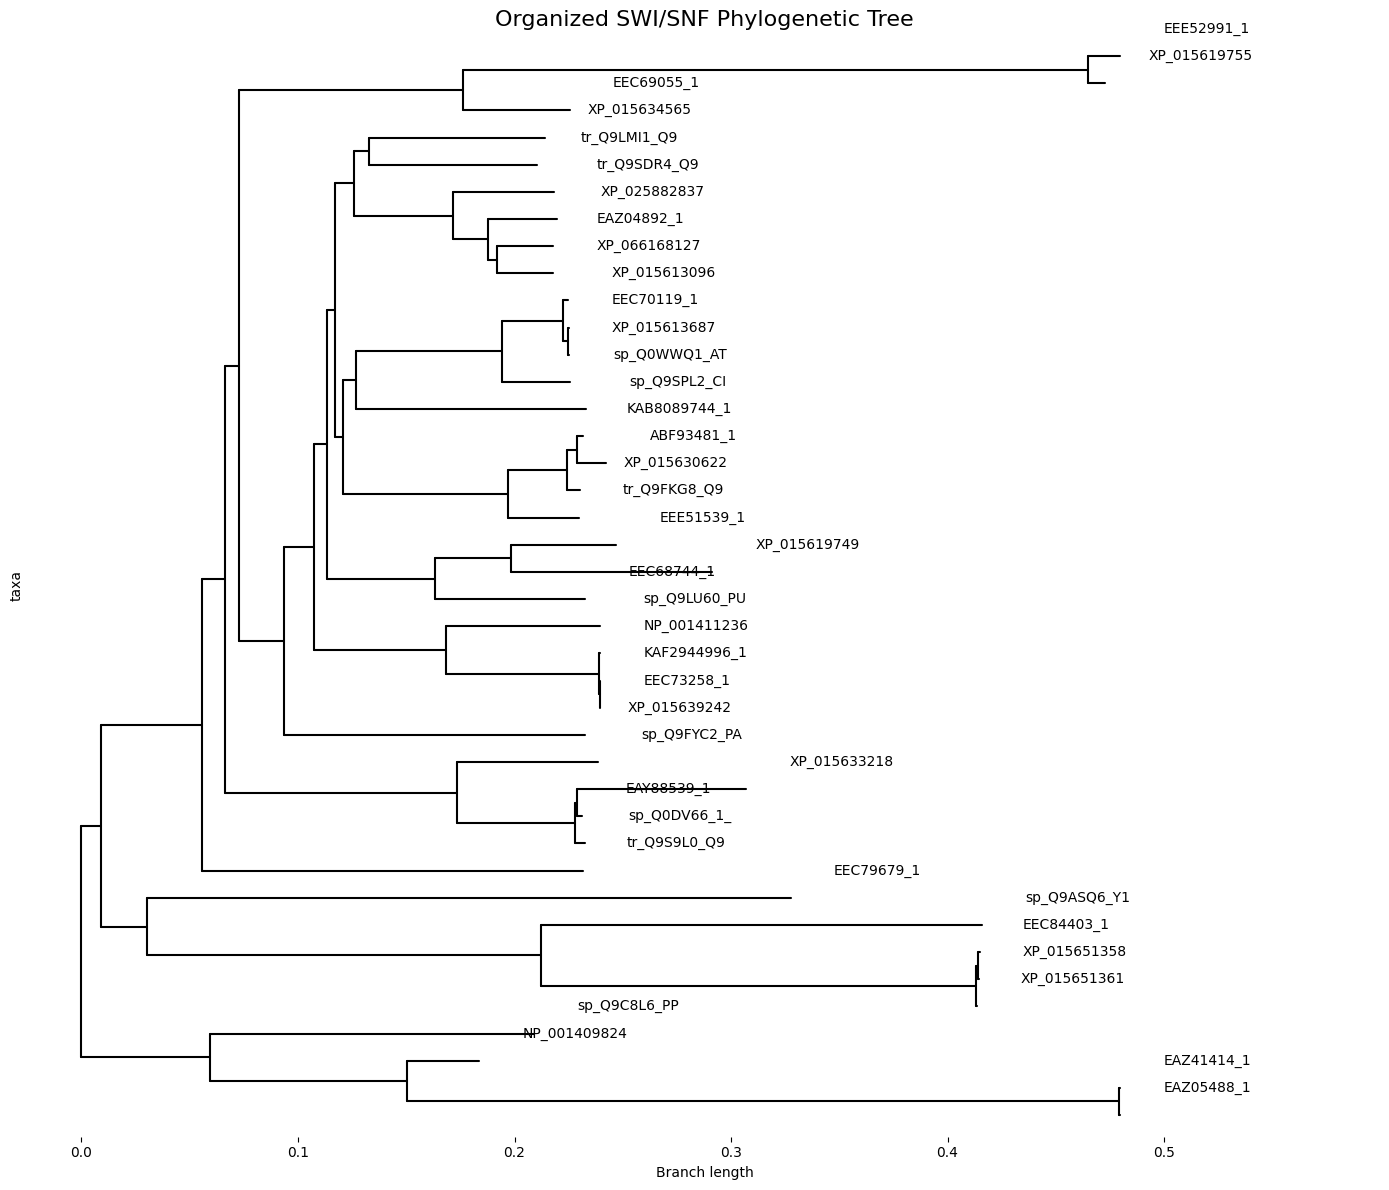

In [51]:
from Bio import Phylo
import matplotlib.pyplot as plt

def get_terminal_y_positions(tree):
    """Generate evenly spaced integer y-positions for terminals."""
    terminals = tree.get_terminals()
    return {clade: i for i, clade in enumerate(terminals)}

def plot_clean_tree(tree, title="Phylogenetic Tree"):
    # Compute y positions
    y_pos = get_terminal_y_positions(tree)

    fig, ax = plt.subplots(figsize=(14, 12))

    # Draw only branches, no default labels
    Phylo.draw(tree, axes=ax, do_show=False, label_func=lambda x: "")

    # Manually add clean labels
    for clade in tree.get_terminals():
        x = tree.distance(clade)
        y = y_pos[clade]

        # Clean name: crop to <=12 chars
        name = clade.name[:12]

        ax.text(
            x + 0.02, y,
            name,
            fontsize=10,
            va='center',
            ha='left',
            rotation=0,  # <--- no diagonal text!
        )

    ax.set_title(title, fontsize=16)
    ax.set_xlabel("Branch length")
    ax.set_yticks([])            # Hide y-axis ticks (cleaner)
    ax.set_frame_on(False)       # Remove border for clean look
    plt.tight_layout()
    plt.show()

# ---- Plot your NJ tree ----
plot_clean_tree(nj_tree, title="Organized SWI/SNF Phylogenetic Tree")
